Epoch 1000/10000, Loss: 0.24480528388168768
Epoch 2000/10000, Loss: 0.16027892124251725
Epoch 3000/10000, Loss: 0.042620223867606194
Epoch 4000/10000, Loss: 0.01674104926572063
Epoch 5000/10000, Loss: 0.009509211646326043
Epoch 6000/10000, Loss: 0.006436235292206041
Epoch 7000/10000, Loss: 0.004794874700415184
Epoch 8000/10000, Loss: 0.0037906230471410427
Epoch 9000/10000, Loss: 0.0031191317747140384
Epoch 10000/10000, Loss: 0.002641310493426259
Testing on training data:
Input: [0 0], Predicted Output: [[0.02435533]], Actual Output: [0]
Input: [0 1], Predicted Output: [[0.94738113]], Actual Output: [1]
Input: [1 0], Predicted Output: [[0.94519654]], Actual Output: [1]
Input: [1 1], Predicted Output: [[0.0648066]], Actual Output: [0]


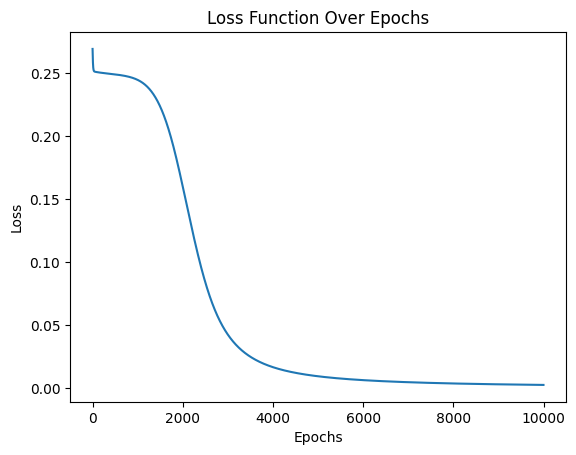

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
# 激活函数及其导数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# 定义神经网络类
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate):
        # 初始化权重和偏置
        self.W1 = np.random.randn(input_size, hidden_size)    
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.zeros((1, output_size))

        self.learning_rate = learning_rate

    # 前向传播
    def forward(self, X):
        
#         print(f'x:{X.shape}')
        
        self.z1 = np.dot(X, self.W1) + self.b1   #净输入值
#         print(f'z1:{self.z1.shape} b1:{self.b1.shape} W1:{self.W1.shape}')
        
        self.a1 = sigmoid(self.z1)               #活性值
        
#         print(f'a1:{self.a1.shape}')
        
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        
#         print(f'z2:{self.z2.shape} b2:{self.b2.shape} W2:{self.W2.shape}')
        
        self.a2 = sigmoid(self.z2)
        
#         print(f'a2:{self.a2.shape}')
        
#         time.sleep(6000)
        return self.a2

    # 反向传播
    def backward(self, X, y, output):
        # 计算输出层误差
        self.output_error = y - output          #误差 
        self.output_delta = self.output_error * sigmoid_derivative(output)

        # 计算隐藏层误差
        self.z1_error = np.dot(self.output_delta, self.W2.T)
        self.z1_delta = self.z1_error * sigmoid_derivative(self.a1)

        # 更新权重和偏置
        self.W2 += self.learning_rate * np.dot(self.a1.T, self.output_delta)
        self.b2 += self.learning_rate * np.sum(self.output_delta, axis=0, keepdims=True)

        self.W1 += self.learning_rate * np.dot(X.T, self.z1_delta)
        self.b1 += self.learning_rate * np.sum(self.z1_delta, axis=0, keepdims=True)

    # 训练模型并记录损失
    def train(self, X, y, epochs):
        loss_history = []  # 存储每个 epoch 的损失值
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)
            
            # 计算损失值并记录
            loss = np.mean(np.square(y - self.forward(X)))
            loss_history.append(loss)

            if (epoch+1) % 1000 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss}")

        return loss_history  # 返回损失历史记录

    # 预测
    def predict(self, X):
        return self.forward(X)

# 示例数据集（异或问题）
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])
# X = np.array([[0,0],
#               ])


y = np.array([[0],
              [1],
              [1],
              [0]])

# y = np.array([[0],
#               ])

# 初始化神经网络
input_size = 2
hidden_size = 4
output_size = 1
learning_rate = 0.1

nn = NeuralNetwork(input_size, hidden_size, output_size, learning_rate)

# 训练模型并获取损失值历史记录
epochs = 10000
loss_history = nn.train(X, y, epochs)

# 绘制损失函数曲线
plt.plot(range(epochs), loss_history)
plt.title('Loss Function Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
# plt.show()

# 测试模型
print("Testing on training data:")
for i in range(len(X)):
    print(f"Input: {X[i]}, Predicted Output: {nn.predict(X[i])}, Actual Output: {y[i]}")


## 定义激活函数及其导数

In [ ]:
# 激活函数及其导数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

$$\sigma (x) = \frac{1}{1+e^{-x}}$$
$$\sigma ^{'}(x) = \sigma (x)(1-\sigma (x))$$

```python
def forward(self, X):
                                            #x:(1, 2) W1:(2, 4)
    self.z1 = np.dot(X, self.W1) + self.b1   # 净输入值      z1:(1, 4) b1:(1, 4) 
    self.a1 = sigmoid(self.z1)               # 激活值   a1:(1, 4) W2:(4, 1)
    
    self.z2 = np.dot(self.a1, self.W2) + self.b2          #z2:(1, 1) b2:(1, 1) 
    self.a2 = sigmoid(self.z2)                      #a2:(1, 1)
    
    return self.a2




前向传播

$$ z_{1} = XW_1 + b1 $$
$$a_{1} = \sigma(z_{1})$$
$$ z_{2} = a_{1}W_2 + b2 $$
$$a_{2} = \sigma(z_{2})$$

```python
def backward(self, X, y, output):
    # 计算输出层误差
    self.output_error = y - output         #  根据损失函数计算error
    self.output_delta = self.output_error * sigmoid_derivative(output)  #计算 delta2   = error * (a2对z2的偏导数）

    # 计算隐藏层误差
    self.z1_error = np.dot(self.output_delta, self.W2.T)     
    self.z1_delta = self.z1_error * sigmoid_derivative(self.a1)   #计算 delta1 = delta2 * W2 * (a1对z1的偏导数）

    # 更新权重和偏置
    self.W2 += self.learning_rate * np.dot(self.a1.T, self.output_delta)
    self.b2 += self.learning_rate * np.sum(self.output_delta, axis=0, keepdims=True)

    self.W1 += self.learning_rate * np.dot(X.T, self.z1_delta)
    self.b1 += self.learning_rate * np.sum(self.z1_delta, axis=0, keepdims=True)
    
    y:(1,1)
    x:(1, 2)
    z1:(1, 4) b1:(1, 4) W1:(2, 4)
    a1:(1, 4)
    z2:(1, 1) b2:(1, 1) W2:(4, 1)
    a2:(1, 1)


反向传播

首先我们定义损失函数
$$ L = \frac{1}{2}(\hat y - y )^2 = \frac{1}{2}(a_2 - y )^2$$

要更新参数我们必须算出损失函数对 $W$ 的导数:
$$ \frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial a_2} \frac{\partial a_2}{\partial z_2} \frac{\partial z_2}{\partial w_2}$$

首先我们计算输出层误差 $\delta _2$
$$\delta_2 = \frac{\partial L}{\partial z_2} = \frac{\partial L}{\partial a_2} \frac{\partial a_2}{\partial z_2}=（y-a_2)\sigma^{'}(z_2)     其中 a_2 = \sigma(z_2)$$
因为 $\frac{\partial z_2}{w_2} = a_1$ $\frac{\partial z_2}{\partial b_2} = 1$  所以：
$$\frac{\partial L}{\partial w_2} = \delta_2 a_2$$
$$\frac{\partial L}{\partial b_2} = \delta_2$$
由梯度更新的公式可得：
$$W_2 = W_2 + \alpha \cdot \delta_2 \cdot a_2$$
$$b_2 = b_2 + \alpha \cdot \delta_2$$
梯度再次回传到Z_1,我们可以计算得到$\delta_1$
$$\delta_1 = \frac{\partial L }{\partial z_1} =\frac{\partial L}{\partial a_2} \frac{\partial a_2}{\partial z_2} \frac{\partial z_2}{\partial a_1}\frac{\partial a_1}{\partial z_1}= \delta_2 \frac{\partial z_2}{\partial a_1}\frac{\partial a_1}{\partial z_1} = \delta_2 W_2 \sigma^{'}(z_1)$$
因为$W_1$是第一层的参数，$\frac{\partial z_1}{\partial w_1} = X$所以可得到梯度更新公式：

$$W_1 = W_1 + \alpha \cdot \delta_1 X$$
$$b_1 = b_1 + \alpha \cdot \delta_1$$

In [ ]:
self.z1_error = np.dot(self.output_delta, self.W2.T)     
self.z1_delta = self.z1_error * sigmoid_derivative(self.a1)

## 定义神经网络

Epoch [1000/10000], Loss: 0.0662
Epoch [2000/10000], Loss: 0.0514
Epoch [3000/10000], Loss: 0.0457
Epoch [4000/10000], Loss: 0.0424
Epoch [5000/10000], Loss: 0.0401
Epoch [6000/10000], Loss: 0.0382
Epoch [7000/10000], Loss: 0.0366
Epoch [8000/10000], Loss: 0.0352
Epoch [9000/10000], Loss: 0.0332
Epoch [10000/10000], Loss: 0.0301


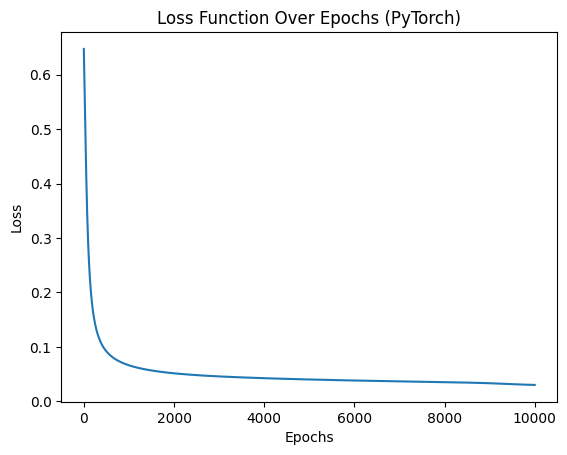

Accuracy on test data: 0.9825


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 加载数据集
data = load_breast_cancer()
X = data['data']
y = data['target']

# 数据标准化
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 将数据转换为 PyTorch 张量
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# 定义神经网络模型
class BreastCancerNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(BreastCancerNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.sigmoid = nn.Sigmoid()
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.sigmoid(out)
        out = self.fc2(out)
        out = self.sigmoid(out)  # 适用于二分类问题
        return out

# 初始化神经网络
input_size = X_train.shape[1]
hidden_size = 4
output_size = 1
learning_rate = 0.1
epochs = 10000

model = BreastCancerNN(input_size, hidden_size, output_size)

# 定义损失函数和优化器
criterion = nn.BCELoss()  # 二分类交叉熵损失
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# 存储每次迭代的损失值
loss_history = []

# 训练神经网络
for epoch in range(epochs):
    # 前向传播
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # 反向传播和优化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 记录损失值
    loss_history.append(loss.item())
    
    if (epoch+1) % 1000 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

# 绘制损失函数曲线
plt.plot(range(epochs), loss_history)
plt.title('Loss Function Over Epochs (PyTorch)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# 测试模型
with torch.no_grad():
    y_pred = model(X_test)
    y_pred_class = y_pred.round()

    # 计算准确率
    accuracy = (y_pred_class.eq(y_test).sum() / float(y_test.shape[0])).item()
    print(f"Accuracy on test data: {accuracy:.4f}")


Epoch 1000/1000, Loss: 0.0024378168938231416


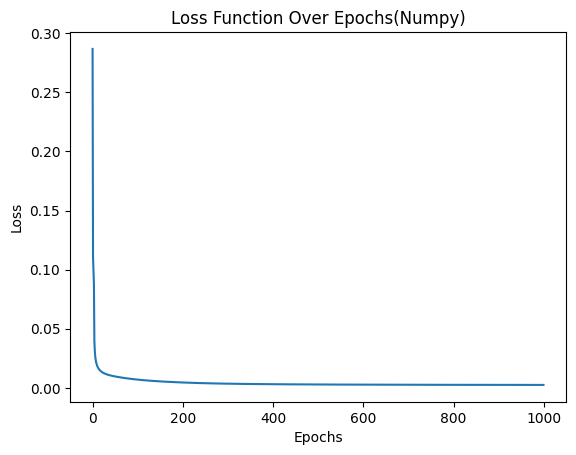

Testing on test data:
Input: [-0.47069438 -0.16048584 -0.44810956 -0.49199876  0.23411429  0.02765051
 -0.10984741 -0.27623152  0.41394897  0.13217601 -0.03274296 -0.31361556
 -0.18269561 -0.22105292 -0.02932749 -0.35591235 -0.16192949 -0.23133322
 -0.32961186 -0.07901817 -0.26903951 -0.16890536 -0.33393537 -0.35629925
  0.4485028  -0.10474068 -0.02441212 -0.19956318  0.18320441  0.19695794], Predicted Output: 0.9969, Actual Output: 1
Input: [ 1.36687747  0.47014935  1.30288585  1.35126414 -0.44622733 -0.02730878
  0.24106404  0.78905995 -0.83832462 -1.16067889  1.38459382 -0.76085133
  1.29695088  1.22577951 -0.86569474 -0.50066625 -0.30516783  0.30882497
 -0.80908274 -0.7931567   1.77900671  0.1470116   1.74660545  1.73227684
 -0.57287347 -0.13145855 -0.01673608  0.97897545 -0.56582801 -1.00057787], Predicted Output: 0.0004, Actual Output: 0
Input: [ 0.37850807  0.04429607  0.40082046  0.26737664  0.91374426  0.34034992
  0.72568592  0.82413977  0.43585463 -0.68578153  0.24949727 -0.

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 加载乳腺癌数据集
data = load_breast_cancer()
X = data['data']
y = data['target']

# 标准化数据
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 将目标 y 形状调整为二维 (n_samples, 1)
y = y.reshape(-1, 1)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# 初始化网络
input_size = X_train.shape[1]  # 输入层大小与数据的特征数量相同
hidden_size = 4  # 可以调整隐藏层大小
output_size = 1  # 输出层为1，因为是二分类任务
learning_rate = 0.1

nn = NeuralNetwork(input_size, hidden_size, output_size, learning_rate)

# 训练网络
epochs = 1000
loss_history = nn.train(X_train, y_train, epochs)

# 绘制损失函数曲线
import matplotlib.pyplot as plt
plt.plot(range(epochs), loss_history)
plt.title('Loss Function Over Epochs(Numpy)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

# 测试网络性能
print("Testing on test data:")
for i in range(len(X_test)):
    prediction = nn.predict(X_test[i].reshape(1, -1))  # 对单个样本进行预测
    print(f"Input: {X_test[i]}, Predicted Output: {prediction[0][0]:.4f}, Actual Output: {y_test[i][0]}")


In [16]:
# 测试网络性能，并计算准确率
def calculate_accuracy(predictions, actuals):
    predictions = np.round(predictions)  # 将预测值四舍五入到0或1
    correct_predictions = np.sum(predictions == actuals)
    accuracy = correct_predictions / len(actuals)
    return accuracy

# 对测试集进行预测
predictions = []
for i in range(len(X_test)):
    prediction = nn.predict(X_test[i].reshape(1, -1))  # 对单个样本进行预测
    predictions.append(prediction[0][0])

predictions = np.array(predictions).reshape(-1, 1)

# 计算准确率
accuracy = calculate_accuracy(predictions, y_test)
print(f"Accuracy on test data: {accuracy:.2f}")


Accuracy on test data: 96.49%
